## 1.1) Data loading and data exploration

In [75]:
# import libraries
import gdown




In [76]:
# import dataset
# Google Drive file ID
file_id = "1XZianrb-YFsa4uVxcXJCVjNcVE2ceMAc"

# Correct download URL format
url = f"https://drive.google.com/uc?id={file_id}"

# Local filename
filename = "diabetes_prediction_dataset.csv"

# Download the file
data = gdown.download(url=url, output=filename, quiet=False)

print("Download completed:", data)

Downloading...
From: https://drive.google.com/uc?id=1XZianrb-YFsa4uVxcXJCVjNcVE2ceMAc
To: c:\Users\MANEL\Documents\data-analytics\machine-learning\ML2\projet_2\diabetes_prediction_dataset.csv
100%|██████████| 3.81M/3.81M [00:00<00:00, 22.6MB/s]


Download completed: diabetes_prediction_dataset.csv


In [77]:
# import data in pandas Frame and analyse it
import pandas as pd

df = pd.read_csv(data)
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [78]:
#data dimensions
df.shape



(100000, 9)

In [79]:
# types data
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [80]:
# statistics describe
df[["age", "bmi", "HbA1c_level", "blood_glucose_level"]].describe()

,age,bmi,HbA1c_level,blood_glucose_level
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,27.320767,5.527507,138.058060
std,22.516840,6.636783,1.070672,40.708136
min,0.080000,10.010000,3.500000,80.000000
25%,24.000000,23.630000,4.800000,100.000000
50%,43.000000,27.320000,5.800000,140.000000
75%,60.000000,29.580000,6.200000,159.000000
max,80.000000,95.690000,9.000000,300.000000


In [81]:
# missing values
df.isnull().sum()
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

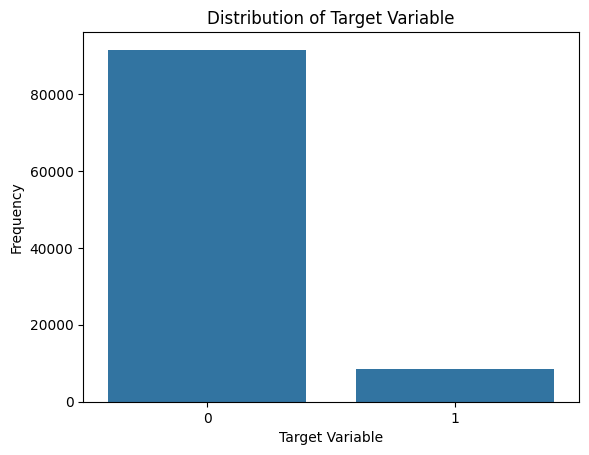

In [82]:
# plot the distribution of the target variable
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="diabetes", data=df)
plt.xlabel("Target Variable")
plt.ylabel("Frequency")
plt.title("Distribution of Target Variable")
plt.show()

In [83]:

# proportion of each class
diabetes_counts = df["diabetes"].value_counts()
diabetes_proportions = (diabetes_counts / len(df)) * 100

print(f"Proportion of non-diabetes cases: {diabetes_proportions[0]:.2f}%")
print(f"Proportion of diabetes cases: {diabetes_proportions[1]:.2f}%")

Proportion of non-diabetes cases: 91.50%
Proportion of diabetes cases: 8.50%


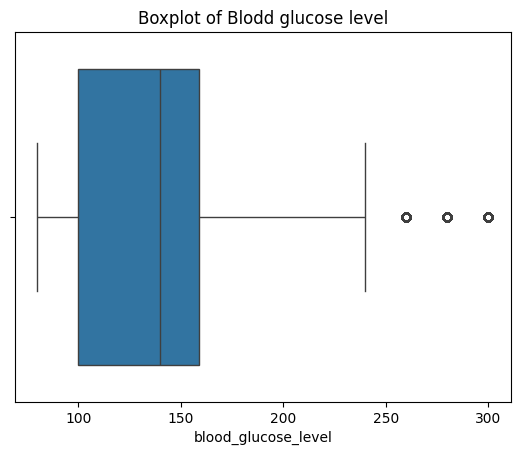

In [84]:
sns.boxplot(x=df["blood_glucose_level"])
plt.title("Boxplot of Blodd glucose level")
plt.show()

In [85]:
# calculate the IQR for the "blood_glucose_level' column"
Q1 = df["blood_glucose_level"].quantile(0.25)
Q3 = df["blood_glucose_level"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["blood_glucose_level"] < lower) | (df["blood_glucose_level"] > upper)]

# compte the number of outliers and the number of outliers with diabetes
nb_diabete = outliers[outliers["diabetes"] == 1].shape[0]

print("number of outliers :", len(outliers))
print("outliers with diabetes :", nb_diabete)

number of outliers : 2038
outliers with diabetes : 2038


An outlier analysis was performed using the IQR method.
Approximately 2.2% of the observations were identified as outliers, all belonging to the diabetic class.
Since these values were within physiologically plausible ranges, they were retained in the dataset to avoid removing potentially informative observations.

### clustering test

In [86]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# select features
features = ["age", "bmi", "blood_glucose_level", "HbA1c_level"]
X = df[features]

# scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
scores = []

# test different numbers of clusters
for k in range(2,10):

    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)

    score = silhouette_score(X_scaled, cluster_labels, sample_size=1000, random_state=42)
    scores.append(score)

    print(f"k = {k}, silhouette score = {score}")

k = 2, silhouette score = 0.21030584790148976
k = 3, silhouette score = 0.20663107129165253
k = 4, silhouette score = 0.23231308852024085
k = 5, silhouette score = 0.22338222462630308
k = 6, silhouette score = 0.2065274542910446
k = 7, silhouette score = 0.22644959242015142
k = 8, silhouette score = 0.2274602413520825
k = 9, silhouette score = 0.22334255199454256


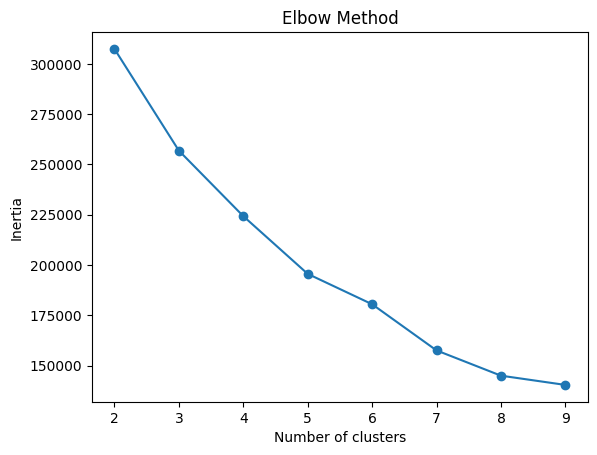

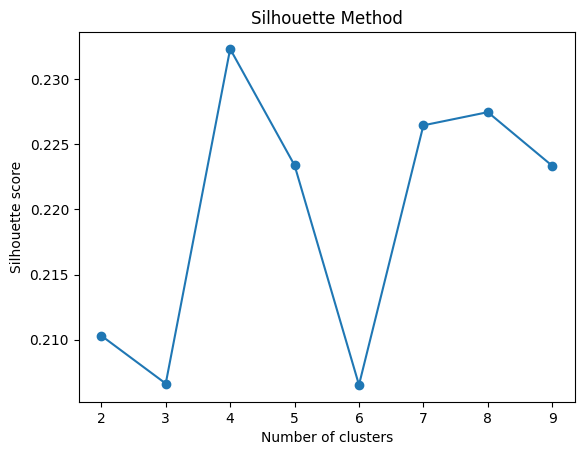

In [87]:

plt.plot(range(2,10), inertia, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

plt.plot(range(2,10), scores, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("Silhouette Method")
plt.show()

The silhouette analysis was used to evaluate the quality of the clustering and determine the optimal number of clusters. The highest silhouette score was obtained for 𝑘=4
k=4, with a value of approximately 0.23. However, this value remains relatively low, indicating that the clusters are not well separated and that the structure of the data is not strongly clusterable. This suggests that the patient profiles form a continuous distribution rather than clearly distinct groups. Consequently, clustering does not appear to be a suitable approach for further analysis in this dataset, and no additional clustering-based experiments were conducted.

## 1.2) data managing

In [88]:
# modified categorical data into numerical data in one hot encoding
df_ohe = pd.get_dummies(df, columns=["smoking_history", "gender"], drop_first=True)
df_ohe.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,gender_Male,gender_Other
0,80.0,0,1,25.19,6.6,140,0,False,False,False,True,False,False,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,False,False,False,True,False,True,False
3,36.0,0,0,23.45,5.0,155,0,True,False,False,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,True,False,False,False,False,True,False


In [89]:
# targets and features in an array
import numpy as np
col_target = "diabetes"
col_features = [c for c in df_ohe.columns if c != col_target]

features = np.array(df_ohe[col_features])
targets = np.array(df_ohe[col_target])

print(f"features shape : {features.shape}")
print(f"targets shape: {targets.shape}")

features shape : (100000, 13)
targets shape: (100000,)


In [90]:
# split the data into training and validation sets
from sklearn.model_selection import train_test_split
train, val, train_targets, val_targets = train_test_split(
    features,
    targets,
    test_size=0.2,
    random_state=42,
    stratify=targets
)

print(f"number of train : {train.shape[0]}")
print(f"number or validation: {val.shape[0]}")
print(f"number of train target : {train_targets.shape[0]}")
print(f"number of validation target : {val_targets.shape[0]}")



number of train : 80000
number or validation: 20000
number of train target : 80000
number of validation target : 20000


In [91]:
number_positive = np.sum(train_targets)
total_samples = len(train_targets)
percentage_positive = (number_positive / total_samples)
print(f"percentage of positive samples in the training set: {percentage_positive:.2%}")
print(f"number of positive : {number_positive}")
print(f"total number of samples: {total_samples}")


percentage of positive samples in the training set: 8.50%
number of positive : 6800
total number of samples: 80000


In [92]:
# standardisation of the data
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)

## 2.1) Model development
### 2.1.1) Logistic Regression method

In [93]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             roc_curve, roc_auc_score, classification_report)
from sklearn.linear_model import LogisticRegression
# Logistic regression model
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(train_scaled, train_targets)

# Predictions
val_preds = model.predict(val_scaled)
val_probs = model.predict_proba(val_scaled)[:, 1]

# Evaluate the regression by recall, f1 and roc/auc
recall = recall_score(val_targets, val_preds)
f1 = f1_score(val_targets, val_preds)
roc_auc_log = roc_auc_score(val_targets, val_probs)
print(f"Recall of the logistic regression model: {recall:.2%}")
print(f"F1 score of the logistic regression model: {f1:.2%}")
print("AUC:", f"{roc_auc_log:.2f}")

Recall of the logistic regression model: 89.41%
F1 score of the logistic regression model: 57.78%
AUC: 0.96


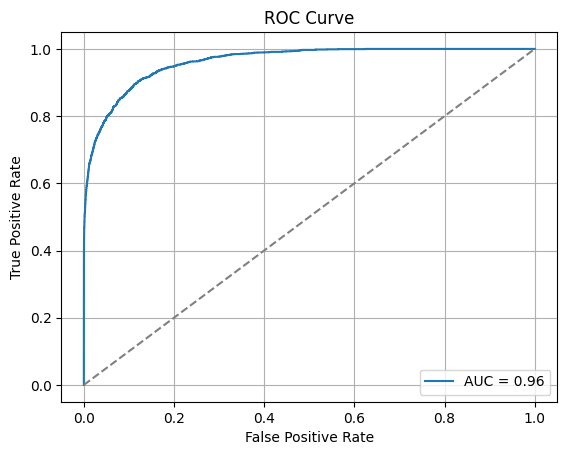

In [94]:
'''
Plot the ROC Curve
'''
fpr, tpr, thesholds = roc_curve(val_targets, val_probs)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_log:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

A clustering approach was applied to identify potential patient subgroups based on metabolic variables. The resulting cluster labels were then added as an additional feature in the classification model. However, the recall metric remained unchanged compared to the baseline model. This indicates that the cluster variable did not introduce additional predictive information, likely because the clustering was derived from features already used by the model.

## 2.1.2) Decision tree classifier

In [95]:
# Decision tree classification
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42, class_weight='balanced')

#train the model
tree.fit(train, train_targets)

#predictions
val_preds_tree = tree.predict(val)

# evaluate recall
recall_tree = recall_score(val_targets, val_preds_tree)
f1_score_tree = f1_score(val_targets, val_preds_tree)
roc_auc_tree = roc_auc_score(val_targets, val_preds_tree)
print(f"Recall of the decision tree model: {recall_tree:.2%}")
print(f"f1 score of the decision tree model: {f1_score_tree:.2%}")
print("AUC:", f"{roc_auc_tree:.2f}")


Recall of the decision tree model: 74.18%
f1 score of the decision tree model: 73.55%
AUC: 0.86


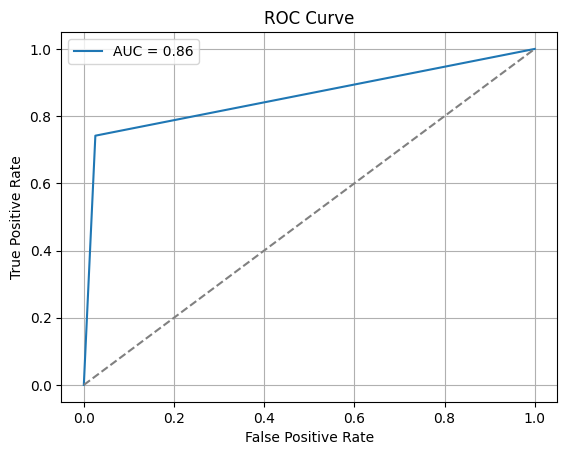

In [96]:
fpr, tpr, thesholds = roc_curve(val_targets, val_preds_tree)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(val_targets, val_preds_tree):.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

# 2.1.3) random forest classifier

In [97]:
# let's try to use a random forest classifier
#from sklearn.ensemble import RandomForestClassifier
#rf = RandomForestClassifier(random_state=42, class_weight='balanced')
#rf.fir(train_scaled, train_targets)


### 2.1.3) Use Deep Learning

Let's  compute class weights for a deep learning model. These weights will be used during training to address class imbalance, ensuring that the model doesn't favor the majority class too heavily.

In [98]:
# calculate the number of positive samples in the training set
number_positive = np.sum(train_targets)
total_samples = len(train_targets)
percentage_positive = (number_positive / total_samples) *100
print(f"The number of diabetes in train data is : {number_positive} ({percentage_positive:.2f} of total)")


The number of diabetes in train data is : 6800 (8.50 of total)


In [99]:
# Define the model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
])

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 64)                896       
                                                                 
 dropout_4 (Dropout)         (None, 64)                0         
                                                                 
 dense_7 (Dense)             (None, 32)                2080      
                                                                 
 dropout_5 (Dropout)         (None, 32)                0         
                                                                 
 dense_8 (Dense)             (None, 1)                 33        
                                                                 
Total params: 3,009
Trainable params: 3,009
Non-trainable params: 0
_________________________________________________________________


In [100]:
# define metrics and compile the model

metrics = [
    keras.metrics.Recall(name='recall'),
    keras.metrics.Precision(name='precision'),
    keras.metrics.AUC(name="auc")
]


model.compile(
    optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=metrics
)

In [101]:
# early stopping callback
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [102]:
# use compute_class_weight to calculate the class weights based on the training targets
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])

class_weight = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_targets)

class_weight_dict = dict(zip(classes, class_weight))
print("class weights:", class_weight_dict)

class weights: {0: 0.546448087431694, 1: 5.882352941176471}


In [103]:
# train the model with class weights

history = model.fit(
    x=train_scaled,
    y=train_targets,
    batch_size=2032,
    epochs = 30,
    verbose = 2,
    validation_data = (val_scaled, val_targets),
    callbacks=[early_stop],
    class_weight = class_weight_dict
)

Epoch 1/30
40/40 - 2s - loss: 0.5444 - recall: 0.7874 - precision: 0.1800 - auc: 0.8116 - val_loss: 0.4374 - val_recall: 0.9365 - val_precision: 0.2801 - val_auc: 0.9467 - 2s/epoch - 46ms/step
Epoch 2/30
40/40 - 0s - loss: 0.3530 - recall: 0.8731 - precision: 0.3099 - auc: 0.9279 - val_loss: 0.2999 - val_recall: 0.9159 - val_precision: 0.3609 - val_auc: 0.9584 - 306ms/epoch - 8ms/step
Epoch 3/30
40/40 - 0s - loss: 0.3038 - recall: 0.8700 - precision: 0.3554 - auc: 0.9429 - val_loss: 0.2765 - val_recall: 0.9088 - val_precision: 0.3805 - val_auc: 0.9607 - 314ms/epoch - 8ms/step
Epoch 4/30
40/40 - 0s - loss: 0.2898 - recall: 0.8784 - precision: 0.3706 - auc: 0.9481 - val_loss: 0.2708 - val_recall: 0.9088 - val_precision: 0.3860 - val_auc: 0.9618 - 292ms/epoch - 7ms/step
Epoch 5/30
40/40 - 0s - loss: 0.2777 - recall: 0.8784 - precision: 0.3817 - auc: 0.9523 - val_loss: 0.2773 - val_recall: 0.9141 - val_precision: 0.3830 - val_auc: 0.9622 - 294ms/epoch - 7ms/step
Epoch 6/30
40/40 - 0s - los

A multilayer perceptron (MLP) was implemented to model the relationship between clinical variables and diabetes status. The network consists of fully connected layers with ReLU activation functions and dropout regularization to prevent overfitting. A sigmoid activation function was used in the output layer to predict the probability of diabetes.

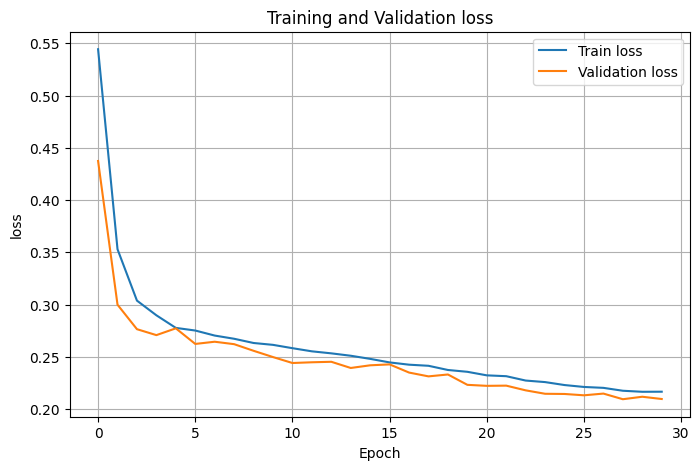

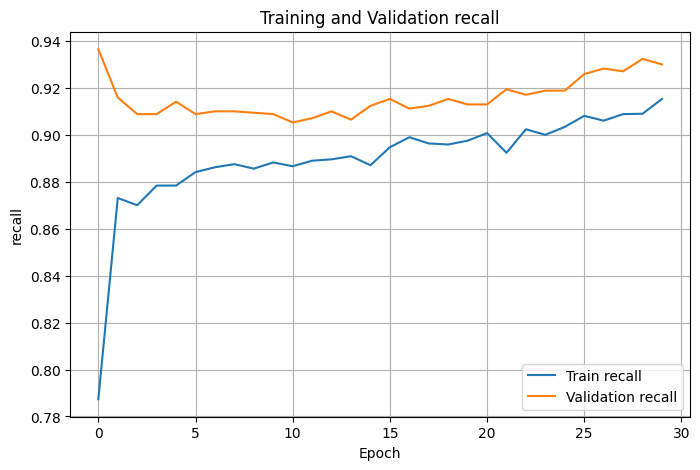

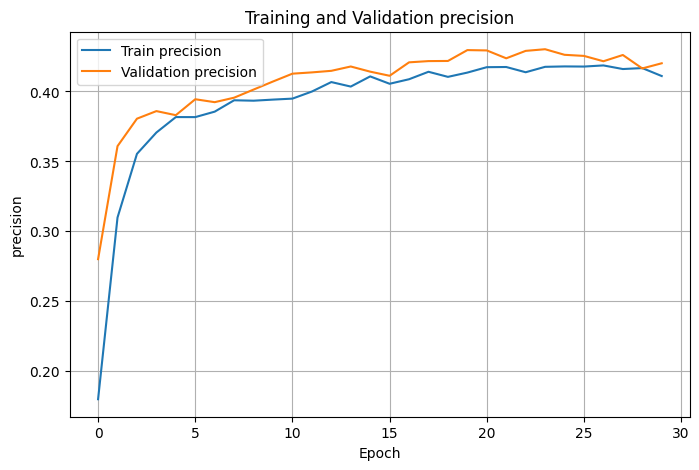

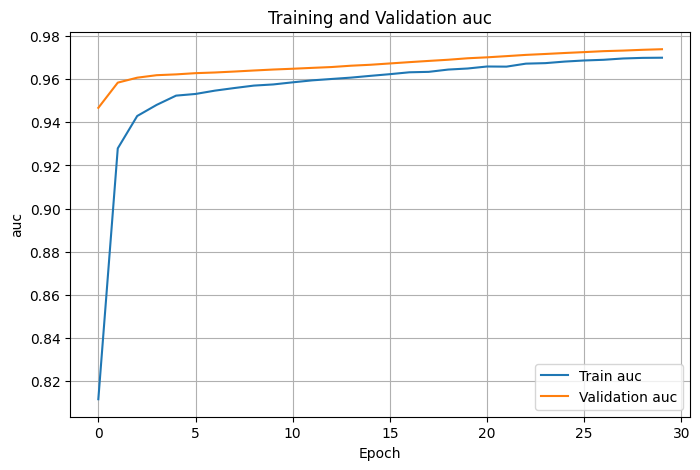

In [104]:
# plot metrics curves
# access the history of training
history_dict = history.history

metrics = [key for key in history_dict.keys() if not key.startswith("val_")]

for metric in metrics:
    plt.figure(figsize=(8, 5))
    plt.plot(history_dict[metric], label=f"Train {metric}")
    
    val_metric = f"val_{metric}"
    if val_metric in history_dict:
        plt.plot(history_dict[val_metric], label=f"Validation {metric}")
    
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"Training and Validation {metric}")
    plt.legend()
    plt.grid(True)
    plt.show()

The training curves indicate that the neural network learns in a stable and consistent manner. Both the training and validation loss decrease steadily throughout the epochs, showing that the model progressively improves its predictions without exhibiting signs of strong overfitting. The recall increases gradually for both datasets and remains slightly higher on the validation set, which suggests that the model maintains good sensitivity for detecting diabetic cases. Precision also improves during training and stabilizes around 0.41–0.42, indicating a reasonable balance between detecting positive cases and limiting false alarms. Finally, the AUC rapidly increases during the first epochs and converges near 0.97 for both training and validation, demonstrating strong discriminative capability. Overall, the close alignment between training and validation metrics suggests that the model generalizes well and does not suffer from significant overfitting. These results indicate that the model achieves robust predictive performance and is suitable for further evaluation and interpretation in a medical screening context.


In [ ]:
# let's evaluate the model on the validation set

y_prob = model.predict(val_scaled)
y_pred = (y_prob > 0.5).astype(int)

625/625 [==============================] - 1s 2ms/step


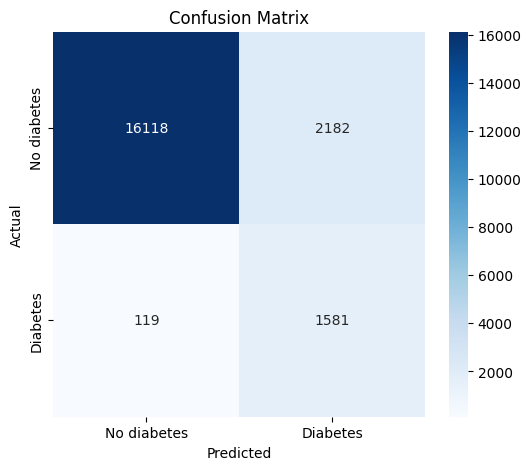

In [106]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(val_targets, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No diabetes", "Diabetes"],
    yticklabels=["No diabetes", "Diabetes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()